# Chest X-ray Image Classification using CNN

**Author:** Waqas Gurmani  

This notebook presents an end-to-end Computer Vision project
for classifying chest X-ray images into:
- Normal
- Pneumonia
- Tuberculosis

The project covers:
- Data loading and preprocessing
- CNN model training from scratch
- Handling class imbalance
- Model evaluation using medical metrics
- Saving the trained model for deployment


## 1. Mount Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Extract Dataset from Google Drive

In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/data.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('.')

print("Zip file extraction Done ✅")

Zip file extraction Done ✅


## 3. Verify Dataset File in Google Drive

In [ ]:
!ls /content/drive/MyDrive/data.zip

/content/drive/MyDrive/data.zip


## 4. Extract Dataset to Local Working Directory

In [ ]:
!unzip -o /content/drive/MyDrive/data.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/train/tuberculosis/tuberculosis-7112.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7113.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7114.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7115.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7116.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7117.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7118.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7119.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7120.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7121.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7122.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7123.jpg  
  inflating: /content/data/train/tuberculosis/tuberculosis-7124.jpg  
  inflating: /content/data/train/tuberc

## 5. Verify Extracted Dataset Structure

In [ ]:
!ls /content/data

data.yaml  test  train	val


## 6. Verify Training Dataset Classes

In [ ]:
!ls /content/data/train

normal	pneumonia  tuberculosis


# 7. Import Required Libraries


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.optimizers import Adam

# Performance Optimization

AUTOTUNE = tf.data.AUTOTUNE


import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 8. Define Dataset Paths

In [ ]:
# Dataset Base Path
BASE_DIR = "/content/data"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

print("Train Path:", TRAIN_DIR)
print("Validation Path:", VAL_DIR)
print("Test Path:", TEST_DIR)

Train Path: /content/data/train
Validation Path: /content/data/val
Test Path: /content/data/test


## 9. Define Image and Training Parameters

In [ ]:
# Image & Training Parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
SEED = 42

## 10. Load Training, Validation, and Test Datasets

In this step, the image datasets are loaded from the directory
structure using TensorFlow's `image_dataset_from_directory` function.

This method automatically:
- Reads images from folders
- Resizes them to a fixed shape
- Assigns class labels based on folder names
- Creates batches for efficient training


In [ ]:
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("✅ Datasets reloaded successfully")

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.
✅ Datasets reloaded successfully


## 11. Extract Class Names and Number of Classes

In this step, we retrieve the class labels automatically
assigned by TensorFlow based on the folder names in the
training dataset.

Knowing the class names and total number of classes is essential for:
- Building the final classification layer
- Interpreting model predictions
- Evaluating class-wise performance


In [ ]:
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

🧠 Classes: ['normal', 'pneumonia', 'tuberculosis']
🔢 Number of classes: 3


## 12. Visualize Sample Training Images

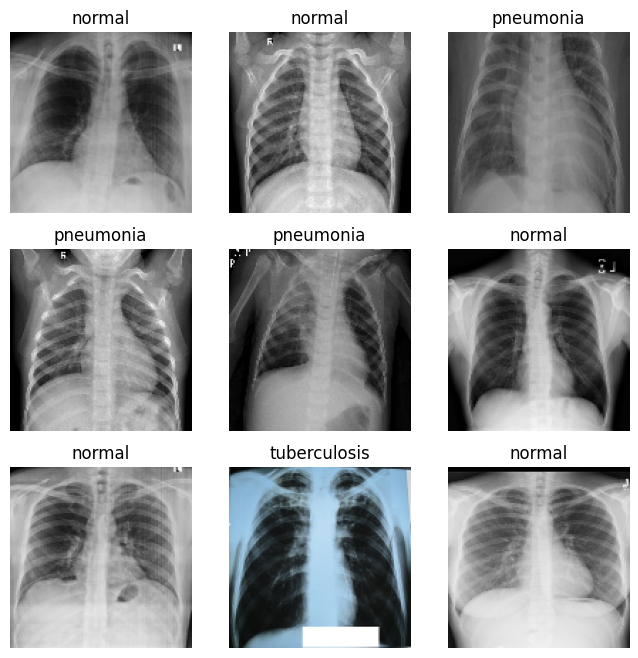

In [ ]:
plt.figure(figsize=(8, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## 13. Image Normalization

In [ ]:
# Normalzation Layer
normalization_layer = tf.keras.layers.Rescaling(1./255)


## 14. Apply Normalization to Datasets

In this step, the normalization layer is applied to the
training, validation, and test datasets.

This ensures that all images are scaled consistently
before being passed to the CNN model.


In [ ]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

print("✅ Normalization applied")

✅ Normalization applied


## 15. Optimize Data Pipeline Performance

In this step, the TensorFlow data pipeline is optimized
to improve training efficiency and reduce input bottlenecks.

Techniques such as shuffling and prefetching help ensure
that the GPU/CPU remains fully utilized during training.

In [ ]:
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)


## 16. Medical-Safe Data Augmentation

In this step, data augmentation techniques are applied to
increase the diversity of the training data.

For medical X-ray images, only **safe transformations** are used
to avoid distorting anatomical structures.

Data augmentation helps:
- Reduce overfitting
- Improve model generalization
- Simulate real-world variations in medical imaging

In [ ]:
# Medical-Safe Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

print("✅ Data augmentation pipeline ready")

✅ Data augmentation pipeline ready


## 17. CNN Model Architecture (From Scratch)

In this step, we build a Convolutional Neural Network (CNN)
from scratch for multi-class chest X-ray image classification.

The model is designed to:
- Extract hierarchical image features
- Remain lightweight and memory-efficient
- Perform well under limited computational resources


In [ ]:
# Simple CNN Model (From Scratch)
model = tf.keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

print("✅ Simple CNN model built")

✅ Simple CNN model built


## 18. Model Summary

In this step, we display a detailed summary of the CNN model
architecture.

The summary provides information about:
- Each layer in the network
- Output shape at every stage
- Number of trainable parameters


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,067 (16.36 MB)

 Trainable params: 4,288,067 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

## 19. Model Compilation

In this step, the CNN model is compiled by defining:
- The optimizer
- The loss function
- The evaluation metrics


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model compiled")

✅ Model compiled


## 20. Model Training with Early Stopping

In this step, the CNN model is trained using the training dataset
and evaluated on the validation dataset.

Early stopping is applied to:
- Prevent overfitting
- Stop training when validation performance stops improving
- Restore the best-performing model weights

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/30
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 235s 72ms/step - accuracy: 0.6432 - loss: 0.7103 - val_accuracy: 0.7257 - val_loss: 0.4859
Epoch 2/30
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 206s 56ms/step - accuracy: 0.7393 - loss: 0.5020 - val_accuracy: 0.7411 - val_loss: 0.4623
Epoch 3/30
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 203s 54ms/step - accuracy: 0.7527 - loss: 0.4704 - val_accuracy: 0.7466 - val_loss: 0.4579
Epoch 4/30
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 217s 70ms/step - accuracy: 0.7486 - loss: 0.4636 - val_accuracy: 0.7537 - val_loss: 0.4324
Epoch 5/30
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 194s 53ms/step - accuracy: 0.7628 - loss: 0.4435 - val_accuracy: 0.7557 - val_loss: 0.4294
Epoch 6/30
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 197s 54ms/step - accuracy: 0.7607 - loss: 0.4363 - val_accuracy: 0.7522 - val_loss: 0.4281
Epoch 7/30
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 215s 70ms/step - accuracy: 0.7614 - loss: 0.4369 - val_accuracy: 0.7620 - val_loss: 0.4230
Epoch 8/30
1279/1279 ━━━━━━━━━━━━━━━━━━━━ 214s 69ms/step - accuracy: 

## 21. Model Evaluation on Test Data

In this step, the trained CNN model is evaluated on the
test dataset, which contains unseen images.

The purpose of this step is to:
- Measure the model’s generalization ability
- Obtain unbiased performance metrics
- Validate real-world performance of the trained model


In [ ]:
# Evaluate on Test Data
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"✅ Test Accuracy: {test_accuracy:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

161/161 ━━━━━━━━━━━━━━━━━━━━ 26s 158ms/step - accuracy: 0.8313 - loss: 0.4881
✅ Test Accuracy: 0.7614
✅ Test Loss: 0.4155


## 22. Generate Predictions on Test Data

In this step, the trained CNN model is used to generate
predictions for the test dataset.



In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1

## 23. Confusion Matrix Analysis

In this step, a confusion matrix is generated to analyze
the class-wise performance of the CNN model.

The confusion matrix helps identify:
- Correct classifications
- Misclassifications between classes
- Class imbalance effects

This analysis is especially important for medical image classification,
where missing a disease case can have serious consequences.


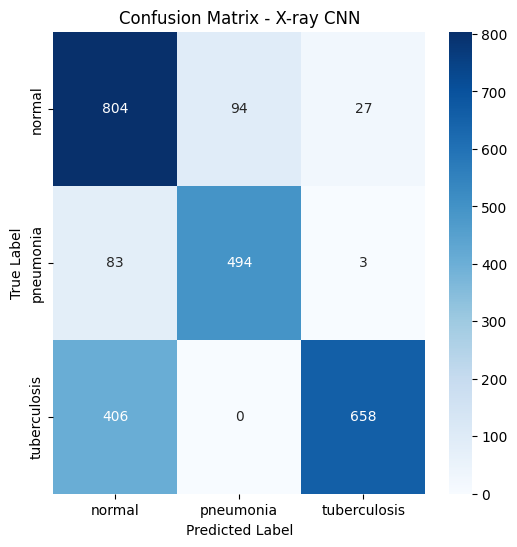

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - X-ray CNN")
plt.show()


## 24. Classification Report

In this step, a detailed classification report is generated
to evaluate the model’s performance for each class individually.

The report includes:
- Precision
- Recall
- F1-score
- Support (number of samples per class)

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      normal       0.62      0.87      0.72       925
   pneumonia       0.84      0.85      0.85       580
tuberculosis       0.96      0.62      0.75      1064

    accuracy                           0.76      2569
   macro avg       0.81      0.78      0.77      2569
weighted avg       0.81      0.76      0.76      2569



## 25. Training and Validation Performance Analysis

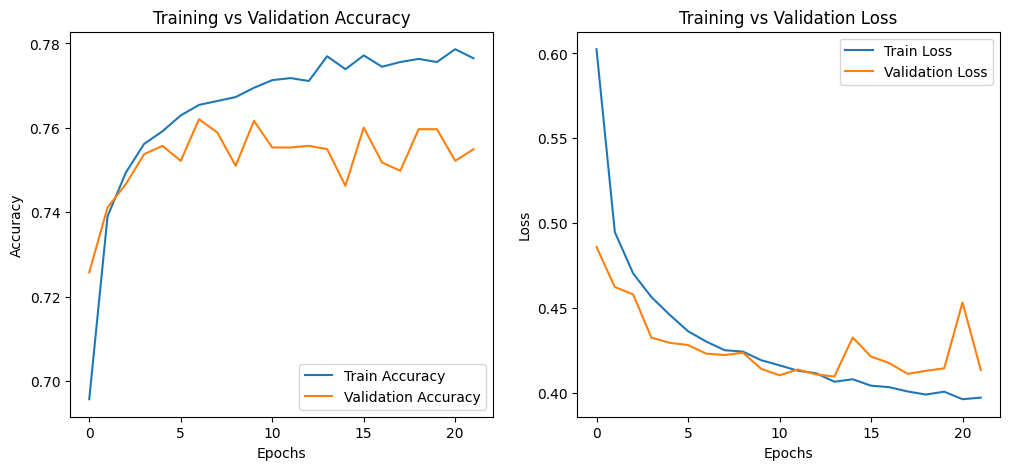

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

## 26. Prediction Distribution by Class


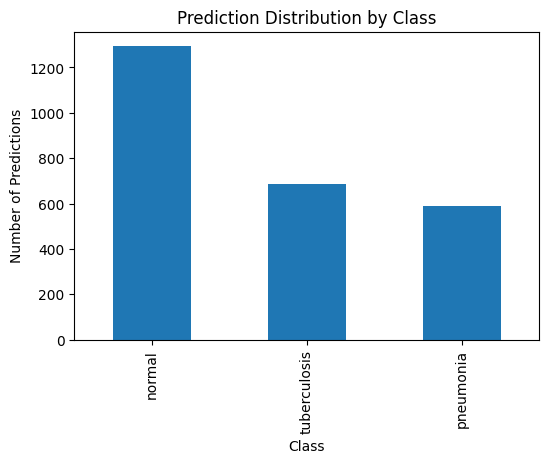

In [ ]:
import pandas as pd

pred_df = pd.DataFrame({
    "True": [class_names[i] for i in y_true],
    "Predicted": [class_names[i] for i in y_pred]
})

plt.figure(figsize=(6,4))
pred_df["Predicted"].value_counts().plot(kind="bar")
plt.title("Prediction Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Number of Predictions")
plt.show()

## 27. Save the Trained Model

In [ ]:
MODEL_PATH = "xray_cnn_model.keras" # Added .keras extension

model.save(MODEL_PATH)

print("✅ Model saved successfully at:", MODEL_PATH)

✅ Model saved successfully at: xray_cnn_model.keras


## 28. Save Trained Model to Google Drive


In [ ]:
import shutil

source_path = MODEL_PATH
destination_path = '/content/drive/MyDrive/xray_cnn_model.keras' # Saving directly to MyDrive

shutil.copy(source_path, destination_path)

print(f"✅ Model successfully copied to Google Drive at: {destination_path}")

✅ Model successfully copied to Google Drive at: /content/drive/MyDrive/xray_cnn_model.keras
